# Reviewer-Score Evaluation

**Premise:** metadiff **F1 is too noisy** to be the basis for evaluation —
~half the cases have a flawed gold (mis-pairing, leakage, base
contamination), and even on clean cases serialization artefacts move F1
a lot. Every agent run was reviewed by **two independent reviewing
agents** (`claude` = Claude Opus 4.7, and `codex`); we use the
**reviewer outcome verdict** as the primary measure
(`success`=1.0, `partial_success`=0.5, `failure`/`no_output`=0.0).

1. Dataset & case statistics (all cases)
2. **Inter-annotator agreement first** — can we trust the reviewer scores?
3. Case statistics (quality, iterations) vs success
4. Agent performance by reviewer score (clear cases)

All per-agent / per-case joins use the authoritative
`(ontology, eval_repo_pr)` key from `scores.tsv` (the free-text `agent`
field in review files is unreliable).


In [1]:
import os
while not os.path.exists('analysis/scores.tsv'):
    os.chdir('..')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from ai4c_scribe.analysis import (
    load_scores, load_reviews, attach_case_quality,
    pair_reviewers, cohen_kappa, reviewer_score,
)
sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.precision', 3)

scores = attach_case_quality(load_scores('analysis/scores.tsv'))
scores['agent'] = pd.read_csv('analysis/scores.tsv', sep='\t')['agent'].values  # canonical handle
reviews = attach_case_quality(load_reviews())

# Authoritative per-eval-PR metadata (canonical agent + case fields)
pr2meta = (scores.dropna(subset=['eval_repo_pr'])
           .assign(eval_repo_pr=lambda d: pd.to_numeric(d.eval_repo_pr, errors='coerce'))
           .drop_duplicates(['ontology','eval_repo_pr'])
           .set_index(['ontology','eval_repo_pr'])
           [['agent','issue_number','case_quality','difficulty','case_type','f1']])

# attempts per (ontology, issue, canonical agent) = "multiple iterations"
att = (scores.groupby(['ontology','issue_number','agent'])['eval_repo_pr']
       .nunique().rename('n_attempts'))

paired = pair_reviewers(reviews)
paired['eval_repo_pr'] = pd.to_numeric(paired['eval_repo_pr'], errors='coerce')
idx = paired.set_index(['ontology','eval_repo_pr']).index
for c in ['agent','issue_number','case_quality','difficulty','case_type','f1']:
    paired[c] = idx.map(pr2meta[c])
paired = paired.dropna(subset=['agent']).copy()      # keep PRs we can attribute
paired['case_quality'] = paired['case_quality'].fillna('unflagged')
paired['n_attempts'] = paired.set_index(['ontology','issue_number','agent']).index.map(att)
paired_clear = paired[paired.case_quality != 'poor'].copy()

print(f'{scores.case.nunique()} cases | {len(scores)} scored runs | '
      f'{len(reviews)} review files')
print(f'{len(paired)} reviewed eval-PRs attributable to an agent '
      f'({len(paired_clear)} on clear cases)')


149 cases | 1662 scored runs | 3357 review files
1634 reviewed eval-PRs attributable to an agent (835 on clear cases)


## 1. Dataset & Case Statistics (all cases)

Cases by quality x ontology:
case_quality   good  ok  poor
ontology                     
cell-ontology     3  12    22
go-ontology      20   3    13
mondo             5  13    19
uberon            7  13    19

Overall case quality:
case_quality
poor    73
ok      41
good    35

Attempts per (case, agent): 34.7% had >1 attempt


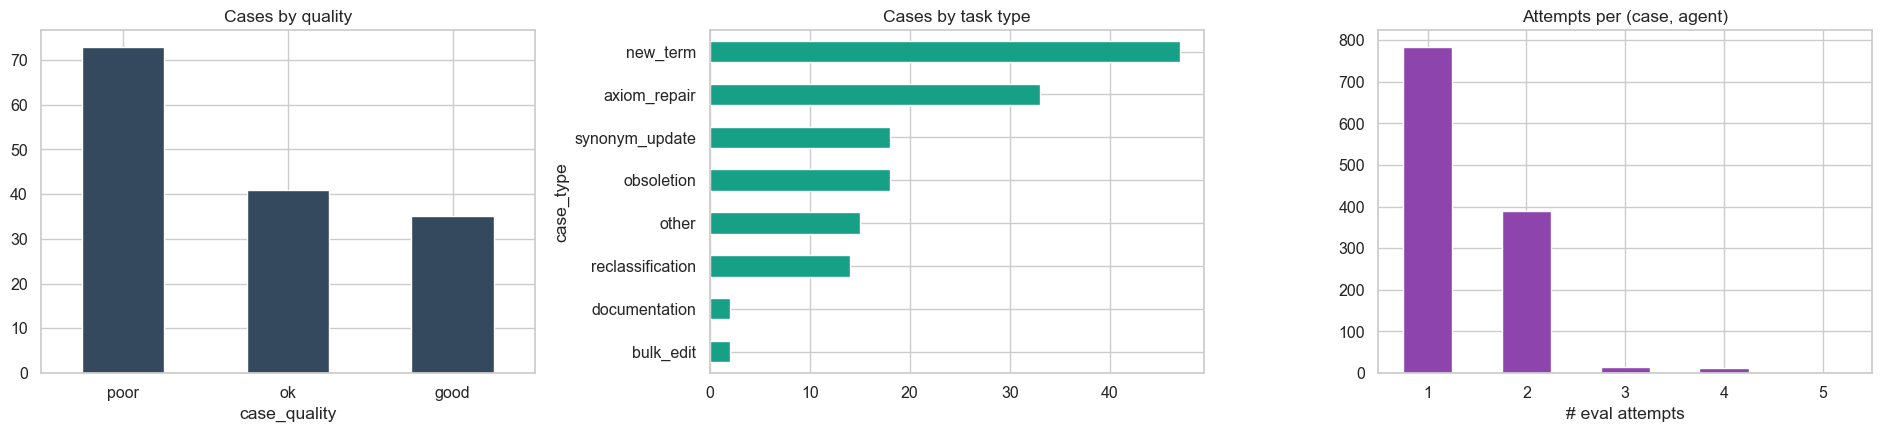

In [2]:
cq_by_ont = (scores.drop_duplicates('case')
             .groupby(['ontology','case_quality']).size().unstack(fill_value=0))
print('Cases by quality x ontology:'); print(cq_by_ont.to_string())
print('\nOverall case quality:')
print(scores.drop_duplicates('case')['case_quality'].value_counts().to_string())

att_df = att.reset_index()
print('\nAttempts per (case, agent): %.1f%% had >1 attempt'
      % (100*(att_df.n_attempts>1).mean()))

fig, ax = plt.subplots(1, 3, figsize=(19,4.5))
scores.drop_duplicates('case')['case_quality'].value_counts().plot.bar(
    ax=ax[0], color='#34495e'); ax[0].set_title('Cases by quality'); ax[0].tick_params(axis='x',rotation=0)
scores.drop_duplicates('case').groupby('case_type').size().sort_values().plot.barh(
    ax=ax[1], color='#16a085'); ax[1].set_title('Cases by task type')
att_df.n_attempts.value_counts().sort_index().plot.bar(
    ax=ax[2], color='#8e44ad'); ax[2].set_title('Attempts per (case, agent)')
ax[2].set_xlabel('# eval attempts'); ax[2].tick_params(axis='x',rotation=0)
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_rv_case_stats.png',dpi=150); plt.show()


## 2. Inter-Annotator Agreement — claude vs codex

Before trusting reviewer scores: do the two reviewing agents agree?
Paired = the same eval PR independently reviewed by both.


Paired reviews (both reviewers): 761
Exact outcome agreement : 0.717
3-point score agreement  : 0.723
Mean |Δ score|           : 0.147
Cohen's kappa (nominal)  : 0.518
Weighted kappa (linear)  : 0.559
Harshness — mean score: claude 0.682 vs codex 0.564


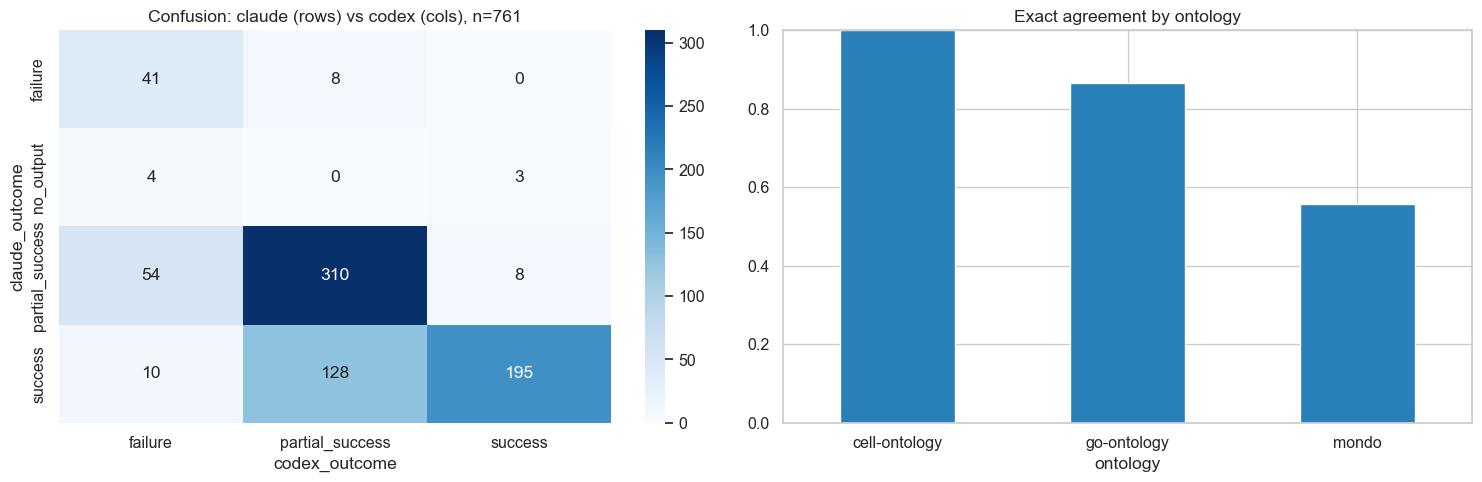


By ontology:
                   n  exact_agree  kappa
ontology                                
cell-ontology   15.0        1.000  1.000
go-ontology    376.0        0.864  0.755
mondo          370.0        0.557  0.240


In [3]:
both = paired.dropna(subset=['claude_score','codex_score']).copy()
n=len(both)
exact = (both.claude_outcome == both.codex_outcome).mean()
agree3 = (both.claude_score == both.codex_score).mean()
mad = (both.claude_score - both.codex_score).abs().mean()
kap = cohen_kappa(both.claude_outcome, both.codex_outcome)
wkap = cohen_kappa(both.claude_score, both.codex_score, weights='linear')
print(f'Paired reviews (both reviewers): {n}')
print(f'Exact outcome agreement : {exact:.3f}')
print(f'3-point score agreement  : {agree3:.3f}')
print(f'Mean |Δ score|           : {mad:.3f}')
print(f"Cohen's kappa (nominal)  : {kap:.3f}")
print(f'Weighted kappa (linear)  : {wkap:.3f}')
print(f'Harshness — mean score: claude {both.claude_score.mean():.3f} '
      f'vs codex {both.codex_score.mean():.3f}')

conf = pd.crosstab(both.claude_outcome, both.codex_outcome)
fig, ax = plt.subplots(1, 2, figsize=(15,5))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f'Confusion: claude (rows) vs codex (cols), n={n}')
by_ont = both.groupby('ontology').apply(
    lambda g: pd.Series({'n':len(g),
        'exact_agree':(g.claude_outcome==g.codex_outcome).mean(),
        'kappa':cohen_kappa(g.claude_outcome,g.codex_outcome) if len(g)>3 else np.nan}))
by_ont['exact_agree'].plot.bar(ax=ax[1], color='#2980b9')
ax[1].set_title('Exact agreement by ontology'); ax[1].set_ylim(0,1); ax[1].tick_params(axis='x',rotation=0)
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_rv_iaa.png',dpi=150); plt.show()
print('\nBy ontology:'); print(by_ont.round(3).to_string())


**Reading it:** κ in the *moderate–substantial* range (and higher
weighted) means the reviewer score is a usable signal. The dominant
disagreement is the soft `partial_success` ↔ `success` boundary; hard
`success` ↔ `failure` flips are rare. `codex` is the harsher reviewer.
Agreement varies by ontology — interpret per-ontology results with that
in mind. Where both reviewers exist we use their **mean (consensus)**;
otherwise the single available reviewer.


## 3. Case Statistics vs Success

Consensus reviewer score by CASE QUALITY (all):
                n   mean  full=1  partial=.5  fail=0
case_quality                                        
good          411  0.830     261         147       3
ok            424  0.594      97         302      25
poor          799  0.641     273         463      63

By DIFFICULTY (clear cases):
              n   mean  full=1  partial=.5  fail=0
difficulty                                        
hard         93  0.653      36          47      10
medium      394  0.724     171         216       7
simple      348  0.710     151         186      11

By TASK TYPE (clear cases):
                    n   mean  full=1  partial=.5  fail=0
case_type                                               
axiom_repair      190  0.771     110          73       7
documentation      21  0.857      15           6       0
new_term          179  0.661      49         126       4
obsoletion        157  0.777      90          61       6
other              92  0.571   

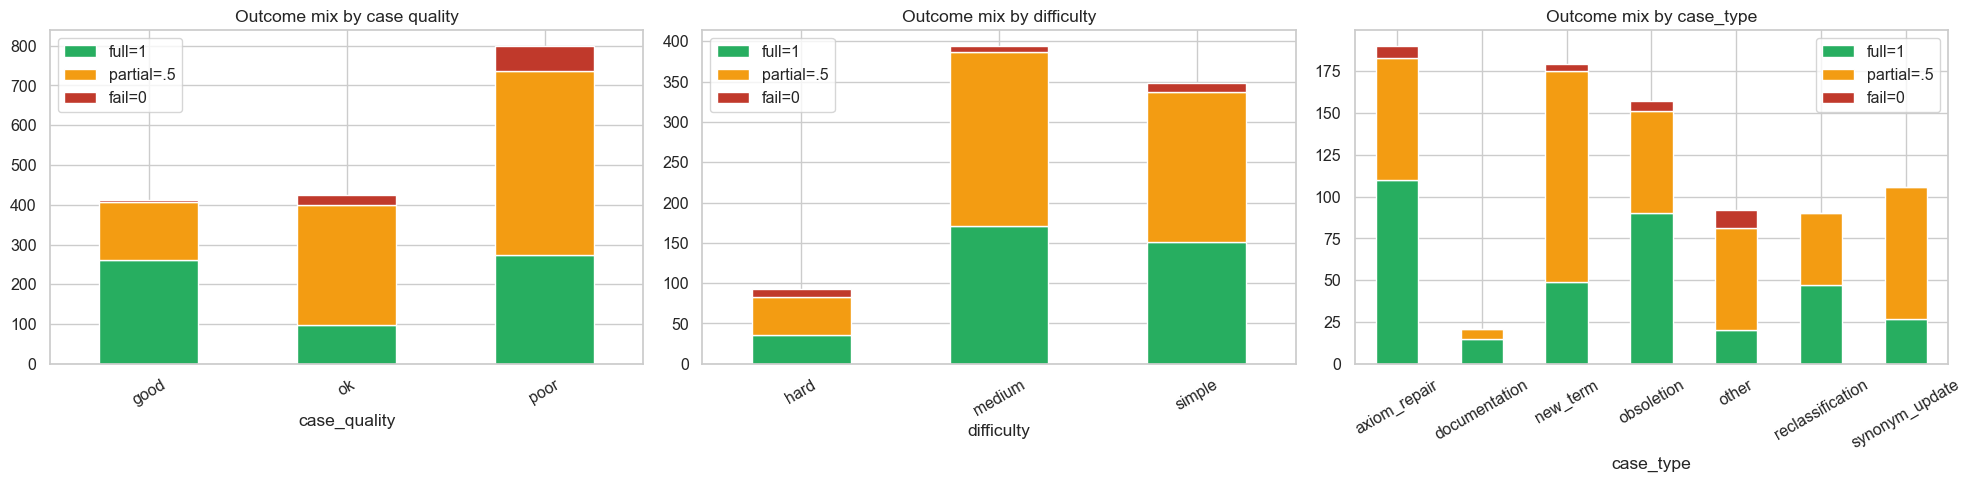

In [4]:
def brk(df, by):
    g = df.groupby(by)['consensus_score']
    out = g.agg(n='count', mean='mean')
    out['full=1']    = df[df.consensus_score==1.0].groupby(by).size()
    out['partial=.5']= df[(df.consensus_score>0)&(df.consensus_score<1)].groupby(by).size()
    out['fail=0']    = df[df.consensus_score==0.0].groupby(by).size()
    return out.fillna(0).astype({'full=1':int,'partial=.5':int,'fail=0':int}).round(3)

print('Consensus reviewer score by CASE QUALITY (all):')
print(brk(paired,'case_quality').to_string())
print('\nBy DIFFICULTY (clear cases):')
print(brk(paired_clear,'difficulty').to_string())
print('\nBy TASK TYPE (clear cases):')
print(brk(paired_clear,'case_type').to_string())

paired_clear['iter_bucket'] = np.where(
    paired_clear['n_attempts'].fillna(1)>1, '>1 attempt', '1 attempt')
print('\nMultiple iterations vs success (clear cases):')
print(brk(paired_clear,'iter_bucket').to_string())

fig, ax = plt.subplots(1, 3, figsize=(20,5))
for a,(d,ti) in zip(ax, [(paired,'case quality'),(paired_clear,'difficulty'),
                          (paired_clear,'case_type')]):
    by = 'case_quality' if ti=='case quality' else ti
    brk(d,by)[['full=1','partial=.5','fail=0']].plot.bar(
        stacked=True, ax=a, color=['#27ae60','#f39c12','#c0392b'])
    a.set_title(f'Outcome mix by {ti}'); a.tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_rv_case_vs_success.png',dpi=150); plt.show()


## 4. Agent Performance by Reviewer Score (clear cases)

Per-agent reviewer score (clear cases, consensus per eval PR):
                              n  mean_score  full_rate  partial_rate  fail_rate
agent                                                                          
std_claude_op47              75       0.820      0.613         0.387      0.000
std_codex_g55                60       0.746      0.417         0.583      0.000
std_opencode_g55            146       0.745      0.479         0.493      0.027
std_claude_son45             82       0.726      0.463         0.512      0.024
std_copilot_son45            58       0.724      0.448         0.534      0.017
std_opencode_gem4            42       0.696      0.381         0.595      0.024
std_opencode_g54            141       0.695      0.433         0.525      0.043
std_codex_g54                76       0.694      0.382         0.592      0.026
std_opencode_kimi            52       0.692      0.327         0.654      0.019
std_claude_hai45            101       0.594      0.297   

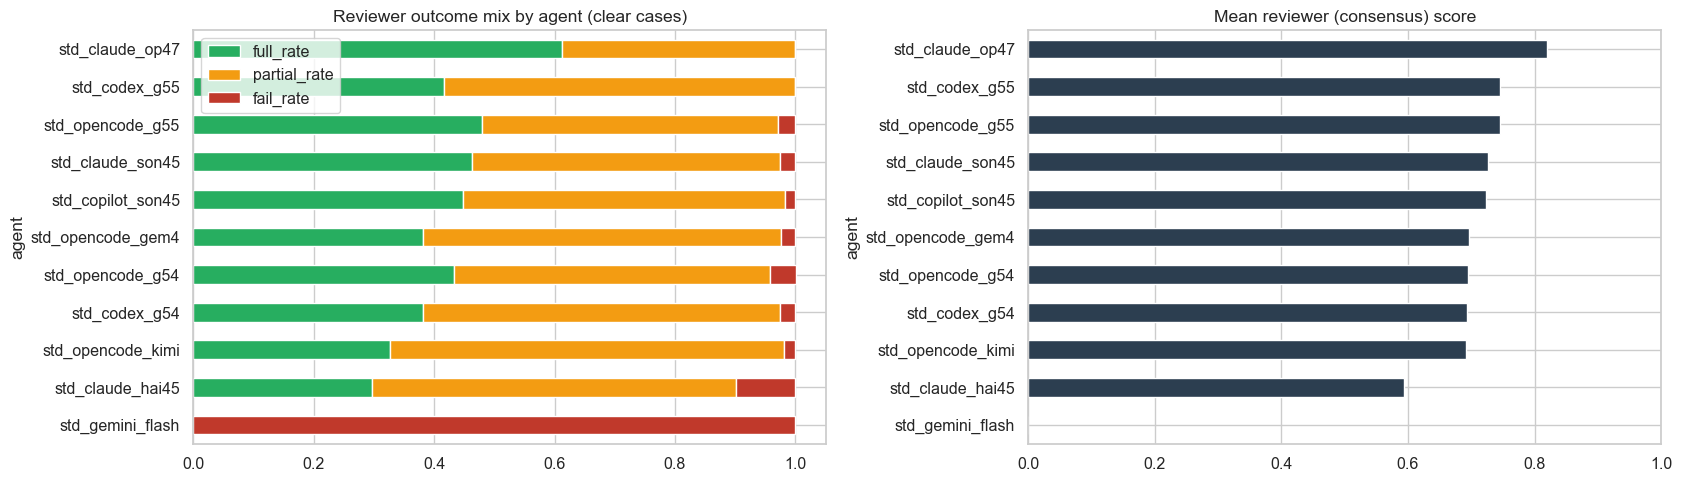


Reviewer (consensus) vs F1 (clear, n=835): Pearson r=0.628, Spearman=0.665
F1 spread WITHIN each consensus level (this is the F1 noise):
                 count   mean    std  median
consensus_score                             
0.00                28  0.211  0.220   0.125
0.25                17  0.212  0.222   0.167
0.50               373  0.500  0.291   0.500
0.75                59  0.709  0.160   0.706
1.00               358  0.855  0.196   0.922


In [5]:
# Per agent: mean consensus score (one row per eval PR) + outcome mix
def agent_breakdown(df):
    g = df.groupby('agent')['consensus_score']
    t = g.agg(n='count', mean_score='mean')
    t['full_rate']    = df[df.consensus_score==1.0].groupby('agent').size()/t['n']
    t['partial_rate'] = df[(df.consensus_score>0)&(df.consensus_score<1)].groupby('agent').size()/t['n']
    t['fail_rate']    = df[df.consensus_score==0.0].groupby('agent').size()/t['n']
    return t.fillna(0).round(3).sort_values('mean_score', ascending=False)

agent_tbl = agent_breakdown(paired_clear)
print('Per-agent reviewer score (clear cases, consensus per eval PR):')
print(agent_tbl.to_string())

std = agent_tbl[agent_tbl.index.str.startswith('std_')]
print('\nBy runtime (std agents):')
rt = paired_clear[paired_clear.agent.str.startswith('std_')].copy()
rt['runtime'] = rt.agent.str.split('_').str[1]
print(rt.groupby('runtime')['consensus_score'].agg(n='count', mean='mean')
      .round(3).sort_values('mean', ascending=False).to_string())

fig, ax = plt.subplots(1, 2, figsize=(17,5))
std[['full_rate','partial_rate','fail_rate']].plot.barh(
    stacked=True, ax=ax[0], color=['#27ae60','#f39c12','#c0392b'])
ax[0].set_title('Reviewer outcome mix by agent (clear cases)'); ax[0].invert_yaxis()
std['mean_score'].plot.barh(ax=ax[1], color='#2c3e50')
ax[1].set_title('Mean reviewer (consensus) score'); ax[1].set_xlim(0,1); ax[1].invert_yaxis()
plt.tight_layout(); plt.savefig('analysis/notebooks/fig_rv_agent.png',dpi=150); plt.show()

# Why not F1: reviewer score vs F1 per eval PR (clear cases)
mm = paired_clear.dropna(subset=['f1','consensus_score']).copy()
mm['f1'] = pd.to_numeric(mm.f1, errors='coerce')
print(f'\nReviewer (consensus) vs F1 (clear, n={len(mm)}): '
      f'Pearson r={mm.consensus_score.corr(mm.f1):.3f}, '
      f'Spearman={mm.consensus_score.corr(mm.f1, method="spearman"):.3f}')
print('F1 spread WITHIN each consensus level (this is the F1 noise):')
print(mm.groupby('consensus_score')['f1'].agg(['count','mean','std','median']).round(3).to_string())


## 5. Takeaways

- **Reviewer scores are stable enough to lead with**: two independent
  reviewing agents agree at the κ quantified in §2 — far more stably
  than F1, whose spread *within* a single reviewer verdict (§4) is huge.
- The §4 agent ranking by reviewer (consensus) score is the headline;
  F1 is retained only as a secondary, noisy signal on clear cases.
- §3 shows how outcome mix varies with case quality, difficulty, task
  type and number of attempts, so those can be controlled for.
- Caveat: per-ontology IAA varies (§2); mondo agreement is weakest, so
  mondo reviewer scores carry more uncertainty.
